## Reading the Knapsack file data

In [29]:
# Function to read the input file and extract the number of items, capacity, values, and weights
def read_file(path):
    # Initializing empty lists to store values and weights
    value_list = []
    weight_list = []
    with open(path) as f:    
        num_items, capacity = map(int, f.readline().split())
        for line in range(int(num_items)):
            (value, weight) = map(int,f.readline().split())
            value_list.append(value)
            weight_list.append(weight)
    return (num_items, capacity, value_list, weight_list)

In [30]:
# Reading the input file and extracting the number of items, capacity, values, and weights
# Note: Please change the path here for the input file you want to read.
(num_items, capacity, value_list, weight_list) = read_file("./dataset/question_1/knapsack-data/23_10000")
print(f'Number of Items: {num_items}, Capacity of bag: {capacity}')
print(f'Values are: {value_list}')
print(f'Weights are: {weight_list}')

Number of Items: 23, Capacity of bag: 10000
Values are: [981, 980, 979, 978, 977, 976, 487, 974, 970, 485, 485, 970, 970, 484, 484, 976, 974, 482, 962, 961, 959, 958, 857]
Weights are: [983, 982, 981, 980, 979, 978, 488, 976, 972, 486, 486, 972, 972, 485, 485, 969, 966, 483, 964, 963, 961, 958, 959]


## Importing the Required packages

In [31]:
import random
import math
import numpy as np
from deap import base, creator, tools

In [32]:
# Mantaining the size of individual chromosome to be equal to the number of items in the knapsack problem
IND_SIZE = num_items
# Defining the Population size for the Genetic Algorithm
POPULATION_SIZE = 50
# Defining the number of generations for the Genetic Algorithm
NUM_OF_GENERATION = 100
# Violating the capacity of the bag will incur a penalty, and this factor determines how much penalty will be applied
VIOLATION_FACTOR = 5
# Defining the mutation rate for the child to be mutated
MUTATION_RATE = 0.20
# Calculating the elite size based on the population size, ensuring it is at least 2
ELITE_SIZE = max(2, int(0.05*POPULATION_SIZE))

### Helper functions

In [33]:
# Function to perform mutation on a child individual
def mutate_child(child):
    if random.random() < MUTATION_RATE:
        # Perform flip mutation on the child
        index = random.randrange(len(child))
        child[index] = 1 - child[index]
    return child

# Evaluation Strategy for each individual chromosome in the population
def do_evaluation(individual):
    # Calcualting the bag value and weight for a individual
    (total_bag_value, total_bag_weight) = calculate_value_and_weight(individual)
    # Caclulating the vilation value
    violation = max(0,  total_bag_weight - capacity)
    # Final Fitness vlaue calculation
    fitness = total_bag_value - VIOLATION_FACTOR * (violation)
    return (fitness,)

# Function to calculate value and weight for one individual chromosome in the population
def calculate_value_and_weight(individual):
    value, weight = 0, 0
    # Iterating through each item in the individual chromosome to calculate the total value and weight
    for index, item in enumerate(individual):
        value += item * value_list[index]
        weight += item * weight_list[index]
    return (value, weight)

# Function to calculate avg of fitness among top n individual
def calculate_avg_fitness(population, n):
    # Selecting the top n individuals based on their fitness values
    top_n_individual_in_gen = tools.selBest(population, n)
    top_n_individual_fitness_avg = 0
    
    for individual in top_n_individual_in_gen:
        top_n_individual_fitness_avg += individual.fitness.values[0] 
    
    return (top_n_individual_fitness_avg / n)

### Registering Functions and Creating Types

In [34]:
# Creating Fitness and Individual Class
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Registering function with the toolbox
toolbox = base.Toolbox()

# Defining the Individual and Population structure for the Genetic Algorithm
toolbox.register("attr_binary", random.choice, [0, 1])
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_binary, n=IND_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
# Evaluation: Custom Method for evaluation
toolbox.register("evaluate", do_evaluation)
# Selection: K-Tournament approach
toolbox.register("select", tools.selTournament, tournsize=3)
# Crossover: Two Point crossover approach
toolbox.register("crossover", tools.cxTwoPoint)
# Mutation: Custom method with 20% Mutation rate for each individual
toolbox.register('mutate', mutate_child)

### Evolutionary Algorithm 

In [35]:
# Seed list for 5 random GA runs
ga_seeds_list = [42, 52, 62, 72, 82]

# A list of list storing fitness of best 5 individual in each generation for each ga runs
convergence_data = list();

# Iterating through each GA run with different seeds
for ga_index, ga_seed in enumerate(ga_seeds_list):
    # Setting the seed using an integer
    random.seed(ga_seed)

    convergence_data.append([]);
    
    # Initializing a initial population
    initial_population = toolbox.population(POPULATION_SIZE)

    # Evaluating fitness for each individual
    for individual in initial_population:
            individual.fitness.values = toolbox.evaluate(individual)
    
    # Iterating through each generation for the current GA run
    for gen_index in range(NUM_OF_GENERATION):
        # Creating a new population for the next generation
        new_population = list()
        
        # Performing Elitism so that we have the best individual carried forward
        elites = tools.selBest(initial_population, ELITE_SIZE)
        elites = list(map(toolbox.clone, elites))
        new_population.extend(elites)

        # Till the new population is filled to the required size, perform selection, crossover, and mutation
        while(len(new_population)<POPULATION_SIZE):
            # Selection: K-Tournament approach - choose two individual for crossover
            offspring = toolbox.select(individuals = initial_population, k = 2)
            # Clone the selected individuals
            [parent1, parent2] = map(toolbox.clone, offspring)
            
            # Crossover: Two Point crossover approach
            [child1, child2] = toolbox.crossover(parent1, parent2)
            
            # Mutation: Custom method with 20% Mutation rate for each individual
            child1 = toolbox.mutate(child1)
            child2 = toolbox.mutate(child2)

            # Evaluating the fitness of the newly created children
            child1.fitness.values = toolbox.evaluate(child1)
            child2.fitness.values = toolbox.evaluate(child2)

            # Adding only if the new population is not yet filled to the required size
            if (len(new_population) < POPULATION_SIZE):
                new_population.append(child1)
                
            if (len(new_population) < POPULATION_SIZE):
                new_population.append(child2)

        # Updating the initial population for the next generation
        initial_population = new_population

        # Calculating the average fitness of the top 5 individuals in the current generation and storing it for convergence analysis
        top_5_individual_fitness_avg = calculate_avg_fitness(new_population, 5)
        # Adding data to convergence_data for the current GA run and generation
        convergence_data[ga_index].append(top_5_individual_fitness_avg)
        # print(f'GA Index: {ga_index + 1}, Generation Index: {gen_index + 1}, Top 5 individual avg fitness: {convergence_data[ga_index][gen_index]}')

    # Printing the best individual and its corresponding value and weight for the current GA run 
    best_individual = tools.selBest(new_population, 1)[0]
    (best_value, best_weight) = calculate_value_and_weight(best_individual)
    # print(f'GA Index: {ga_index + 1}, Best value: {best_value}, Best Weight: {best_weight}, Bag Capacity: {capacity}')

### Convergence Curve Plotting and Data Calculation

In [38]:
# Calculating the average fitness of best 5 individuals across generations for all GA runs
x_list = np.arange(1, NUM_OF_GENERATION + 1)
y_list = []

# Iterating through each generation
for col in range(NUM_OF_GENERATION):
    # Calculating the sum of fitness values
    sum_across_each_generation = 0
    # Iterating through each GA run to calculate the sum of fitness values for the current generation
    for ga_run in range(len(convergence_data)):
        sum_across_each_generation += convergence_data[ga_run][col]
    y_list.append(sum_across_each_generation / len(convergence_data))

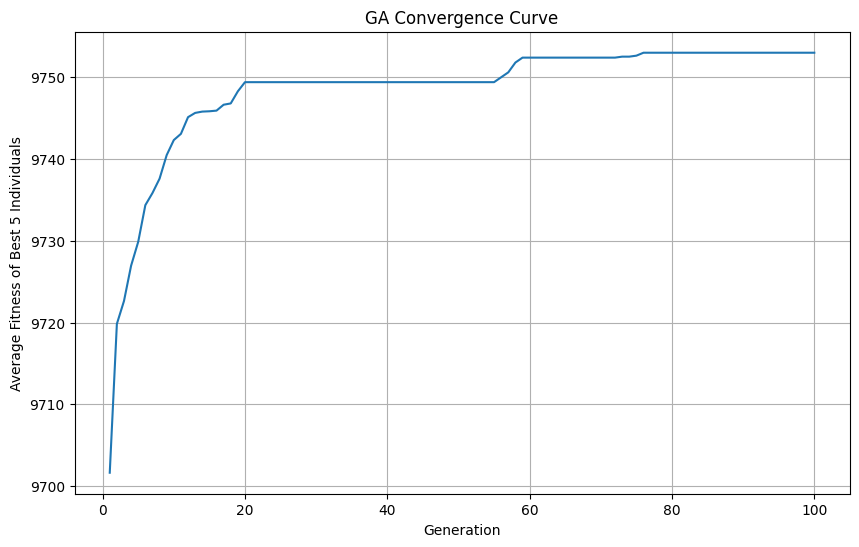

In [39]:
# Plotting the convergence curve for the average fitness of best 5 individuals across generations
import matplotlib.pyplot as plt

# Plot convergence curve
plt.figure(figsize=(10, 6))

plt.plot(x_list, y_list)

plt.xlabel("Generation")
plt.ylabel("Average Fitness of Best 5 Individuals")
plt.title("GA Convergence Curve")

plt.grid(True)
plt.show()